In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing import image

In [2]:
dataset_path = r"C:\san\project cnn\archive\dataset-resized"
img_size = 128
batch_size = 32

In [3]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [4]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)


test_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [5]:
class_names = list(train_data.class_indices.keys())

print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [6]:
model = Sequential()



model.add(
    Input(shape=(128,128,3))
)


model.add(
    Conv2D(
        32,
        (3,3),
        activation="relu"
    )
)

# Pooling Layer 1
model.add(
    MaxPooling2D(2,2)
)



model.add(
    Conv2D(
        64,
        (3,3),
        activation="relu"
    )
)

model.add(
    MaxPooling2D(2,2)
)




model.add(
    Conv2D(
        128,
        (3,3),
        activation="relu"
    )
)

# Pooling Layer 3
model.add(
    MaxPooling2D(2,2)
)



# Feature Extraction
model.add(
    Flatten()
)




model.add(
    Dense(
        128,
        activation="relu"
    )
)


model.add(
    Dropout(0.5)
)



# Output Layer
model.add(
    Dense(
        6,
        activation="softmax"
    )
)


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=20
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 43s 624ms/step - accuracy: 0.2915 - loss: 1.6757 - val_accuracy: 0.3559 - val_loss: 1.5655
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 610ms/step - accuracy: 0.3829 - loss: 1.4635 - val_accuracy: 0.3400 - val_loss: 1.6195
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 612ms/step - accuracy: 0.4387 - loss: 1.3585 - val_accuracy: 0.4453 - val_loss: 1.4500
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 615ms/step - accuracy: 0.4822 - loss: 1.3049 - val_accuracy: 0.4314 - val_loss: 1.3684
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 615ms/step - accuracy: 0.5069 - loss: 1.2262 - val_accuracy: 0.4374 - val_loss: 1.3932
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 624ms/step - accuracy: 0.5242 - loss: 1.2154 - val_accuracy: 0.4732 - val_loss: 1.3667
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 617ms/step - accuracy: 0.5534 - loss: 1.1462 - val_accuracy: 0.4652 - val_loss: 1.3292
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 604ms/step - accuracy: 0.5954 - loss: 1.0875 - val_accu

In [10]:
print(f"Training Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1] * 100:.2f}%")

Training Accuracy: 69.07%
Validation Accuracy: 57.85%


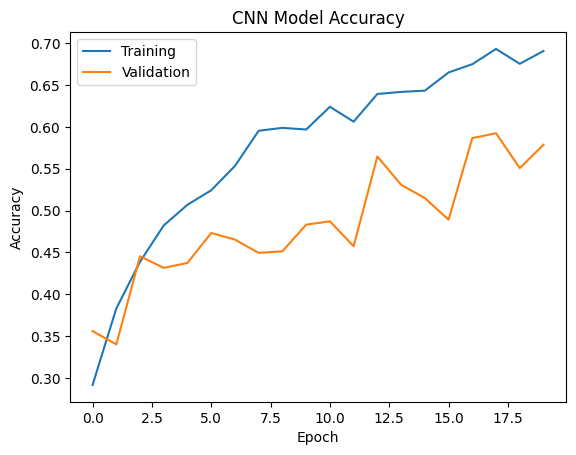

In [11]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("CNN Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(
    ["Training","Validation"]
)

plt.show()

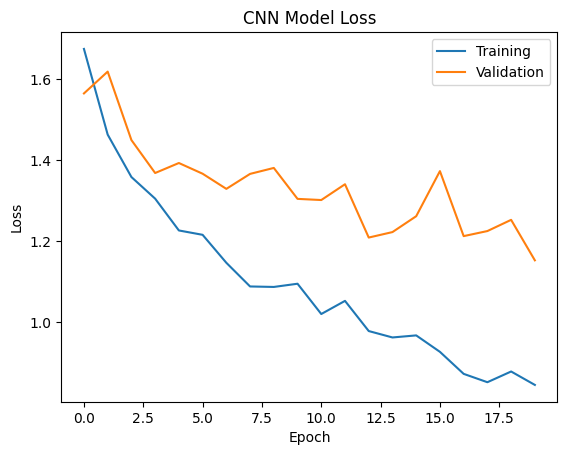

In [12]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("CNN Model Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(
    ["Training","Validation"]
)

plt.show()

In [13]:
model.save("waste_classification_cnn.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [14]:
import os

glass_path = r"C:\san\project cnn\archive\dataset-resized\glass"

print(os.listdir(glass_path)[:10])

['glass1.jpg', 'glass10.jpg', 'glass100.jpg', 'glass101.jpg', 'glass102.jpg', 'glass103.jpg', 'glass104.jpg', 'glass105.jpg', 'glass106.jpg', 'glass107.jpg']


In [15]:
test_image = r"C:\san\project cnn\archive\dataset-resized\glass\glass1.jpg"

print(test_image)

C:\san\project cnn\archive\dataset-resized\glass\glass1.jpg


In [16]:
import os

print(os.path.exists(
r"C:\Users\Admin\Downloads\dataset-resized\dataset-resized\glass"
))

False


In [17]:

img = image.load_img(
    test_image,
    target_size=(128,128)
)


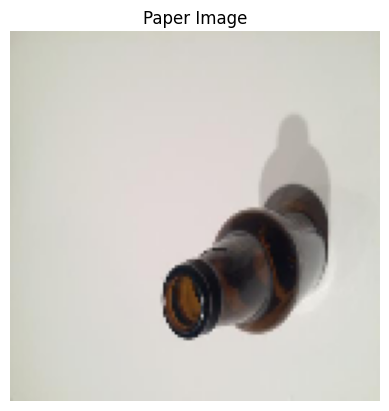

In [18]:

plt.imshow(img)
plt.title("Paper Image")
plt.axis("off")
plt.show()


In [19]:


img_array = image.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

img_array = img_array / 255.0


In [20]:

prediction = model.predict(img_array)


class_names = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


In [21]:


for i in range(len(class_names)):
    print(
        class_names[i],
        ":",
        round(prediction[0][i]*100,2),
        "%"
    )


cardboard : 0.56 %
glass : 5.46 %
metal : 7.93 %
paper : 77.08 %
plastic : 8.71 %
trash : 0.26 %


In [22]:


predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction)*100


print("--------------------")
print("Predicted Waste Type :", predicted_class)
print("Confidence :", round(confidence,2), "%")

--------------------
Predicted Waste Type : paper
Confidence : 77.08 %
